In [11]:
import datetime
import pathlib

In [12]:
import cftime

In [13]:
import xarray

In [14]:
import matplotlib.pyplot
import cartopy

In [15]:
root_dir = pathlib.Path('/gws/pw/j25/cp4a/HadGEM3-GC31-MM-HIST')
root_dir

PosixPath('/gws/pw/j25/cp4a/HadGEM3-GC31-MM-HIST')

In [17]:
var_dict = {
    'ta850': root_dir / 'ta850',
    'ta700': None,
    'ta500': None,
    'ua700': None,
    'va700': None,
    'zg500': root_dir / 'zg500',
    'hus850': None,
    'pr': root_dir / 'pr',

}

In [18]:
var_title={
    'ta850': 'ta850_GC6hrPtUV',
    'pr': 'pr_GC1hr',
    'zg500': 'zg500_GC6hrPtUV'
}
var_model = {
    'ta850': 'HadGEM3-GC31-MM',
    'zg500': 'HadGEM3-GC31-MM',
    'pr': 'HadGEM3-GC31-MM-HIST',
}

In [19]:
#ta850_GC6hrPtUV_HadREM-CP4A-4p5km_HadGEM3-GC31-MM_r1i1p1f3_gn_200201010300-200202010000.nc

In [20]:
fname_template = '{title}_HadREM-CP4A-4p5km_{model}_r1i1p1f3_gn_{start_dt}-{end_dt}.nc'
fname_template

'{title}_HadREM-CP4A-4p5km_{model}_r1i1p1f3_gn_{start_dt}-{end_dt}.nc'

In [21]:
dt_format_template = '{dt.year}{dt.month:02d}{dt.day:02d}{dt.hour:02d}{dt.minute:02d}'

In [22]:
start_dict = {
    'ta850': cftime.Datetime360Day(2002,1,1,3,0),
    'pr': cftime.Datetime360Day(2002,1,1,0,30),
    'zg500': cftime.Datetime360Day(2002,1,1,3,0),
}
end_dict = {
    'ta850': cftime.Datetime360Day(2002,2,1,0,0),
    'pr': cftime.Datetime360Day(2002,1,30,23,30),
    'zg500': cftime.Datetime360Day(2002,2,1,0,0),
}

In [23]:
select_var = 'ta850'
ta850_var_path = var_dict[select_var] / fname_template.format(
    title = var_title[select_var],
    model = var_model[select_var],
    start_dt=dt_format_template.format(dt=start_dict[select_var]),
    end_dt=dt_format_template.format(dt=end_dict[select_var]),
)
print(ta850_var_path.is_file())
ta850_var_path

True


PosixPath('/gws/pw/j25/cp4a/HadGEM3-GC31-MM-HIST/ta850/ta850_GC6hrPtUV_HadREM-CP4A-4p5km_HadGEM3-GC31-MM_r1i1p1f3_gn_200201010300-200202010000.nc')

In [24]:
ta850_ds = xarray.open_dataset(ta850_var_path)
ta850_ds 

<xarray.Dataset> Size: 2GB
Dimensions:   (lon: 2000, bnds: 2, lat: 2101, time: 120)
Coordinates:
  * lon       (lon) float64 16kB -24.52 -24.48 -24.44 -24.4 ... 56.36 56.4 56.44
  * lat       (lat) float64 17kB -45.55 -45.5 -45.46 -45.42 ... 39.42 39.46 39.5
  * time      (time) object 960B 2002-01-01 06:00:00 ... 2002-02-01 00:00:00
    plev      float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    lon_bnds  (lon, bnds) float64 32kB ...
    lat_bnds  (lat, bnds) float64 34kB ...
    ta850     (time, lat, lon) float32 2GB ...
Attributes: (12/41)
    CDI:                   Climate Data Interface version 2.4.1 (https://mpim...
    Conventions:           CF-1.7 CMIP-6.2
    source:                HadREM-CP4A-4p5km (2023)
    institution:           Met Office Hadley Centre, Fitzroy Road, Exeter, De...
    activity_id:           DECK
    branch_method:         no parent
    ...                    ...
    variable_id:           ta850
    variable_name:         ta850
    variant_label:         r1i1p1f3
    license:               CP4A model data is licensed for Non-Commercial Res...
    cmor_version:          3.8.0
    CDO:                   Climate Data Operators version 2.4.1 (https://mpim...

In [25]:
ta850_ds['time'].min(), ta850_ds['time'].max()

(<xarray.DataArray 'time' ()> Size: 8B
 array(cftime.Datetime360Day(2002, 1, 1, 6, 0, 0, 0, has_year_zero=True),
       dtype=object)
 Coordinates:
     plev     float64 8B ...,
 <xarray.DataArray 'time' ()> Size: 8B
 array(cftime.Datetime360Day(2002, 2, 1, 0, 0, 0, 0, has_year_zero=True),
       dtype=object)
 Coordinates:
     plev     float64 8B ...)

In [26]:
# ta850_ds.mean(['lat','lon'])['ta850'].plot.line()

In [27]:
float(ta850_ds['lat'].min()), float(ta850_ds['lat'].max())

(-45.545249938964844, 39.50475311279297)

In [28]:
float(ta850_ds['lon'].min()), float(ta850_ds['lon'].max())

(-24.520263671875, 56.439239501953125)

(array([  26921.,   91210.,  211873.,  263246.,  566115.,  630005.,
         534427., 1001501.,  738838.,   41087.]),
 array([266.95654297, 269.98568726, 273.01483154, 276.04394531,
        279.0730896 , 282.10223389, 285.13137817, 288.16052246,
        291.18963623, 294.21878052, 297.2479248 ]),
 <BarContainer object of 10 artists>)

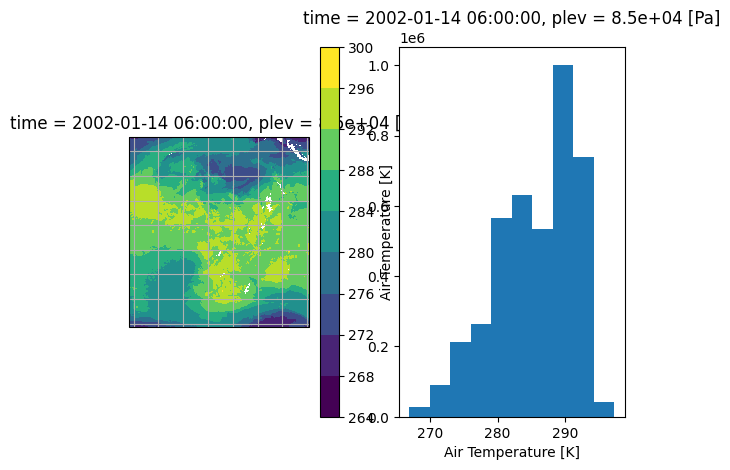

In [29]:
fig1 = matplotlib.pyplot.figure()
ax1 = fig1.add_subplot(1,2,1,projection=cartopy.crs.Mercator())
plot1 = ta850_ds['ta850'].loc['2002-01-14 06:00'][0].plot.contourf(ax=ax1)
ax1.axes.coastlines()
ax1.axes.gridlines()
ax1 = fig1.add_subplot(1,2,2)
ta850_ds['ta850'].loc['2002-01-14 06:00'][0].plot.hist(ax=ax1)

In [30]:
select_var = 'zg500'
zg500_var_path = var_dict[select_var] / fname_template.format(
    title = var_title[select_var],
    model = var_model[select_var],
    start_dt=dt_format_template.format(dt=start_dict[select_var]),
    end_dt=dt_format_template.format(dt=end_dict[select_var]),
)
print(zg500_var_path.is_file())
zg500_var_path

True


PosixPath('/gws/pw/j25/cp4a/HadGEM3-GC31-MM-HIST/zg500/zg500_GC6hrPtUV_HadREM-CP4A-4p5km_HadGEM3-GC31-MM_r1i1p1f3_gn_200201010300-200202010000.nc')

In [33]:
zg500_ds = xarray.open_dataset(zg500_var_path)
zg500_ds 

<xarray.Dataset> Size: 2GB
Dimensions:   (lon: 2000, bnds: 2, lat: 2101, time: 120)
Coordinates:
  * lon       (lon) float64 16kB -24.52 -24.48 -24.44 -24.4 ... 56.36 56.4 56.44
  * lat       (lat) float64 17kB -45.55 -45.5 -45.46 -45.42 ... 39.42 39.46 39.5
  * time      (time) object 960B 2002-01-01 06:00:00 ... 2002-02-01 00:00:00
    plev      float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    lon_bnds  (lon, bnds) float64 32kB ...
    lat_bnds  (lat, bnds) float64 34kB ...
    zg500     (time, lat, lon) float32 2GB ...
Attributes: (12/41)
    CDI:                   Climate Data Interface version 2.4.1 (https://mpim...
    Conventions:           CF-1.7 CMIP-6.2
    source:                HadREM-CP4A-4p5km (2023)
    institution:           Met Office Hadley Centre, Fitzroy Road, Exeter, De...
    activity_id:           DECK
    branch_method:         no parent
    ...                    ...
    variable_id:           zg500
    variable_name:         zg500
    variant_label:         r1i1p1f3
    license:               CP4A model data is licensed for Non-Commercial Res...
    cmor_version:          3.8.0
    CDO:                   Climate Data Operators version 2.4.1 (https://mpim...

## plotting precipitation

In [ ]:
select_var = 'pr'
pr_var_path = var_dict[select_var] / fname_template.format(
    title = var_title[select_var],
    model = var_model[select_var],
    start_dt=dt_format_template.format(dt=start_dict[select_var]),
    end_dt=dt_format_template.format(dt=end_dict[select_var]),
)
print(pr_var_path.is_file())
pr_var_path

In [ ]:
pr_ds = xarray.open_dataset(select_var_path)

In [ ]:
pr_ds

In [ ]:
fig1 = matplotlib.pyplot.figure()
ax1 = fig1.add_subplot(1,1,1,projection=cartopy.crs.Mercator())
plot1 = pr_ds['pr'].loc['2002-01-17 00:30'][0].plot.contourf(ax=ax1)
ax1.axes.coastlines()
ax1.axes.gridlines()


In [32]:
pr_ds['pr'].loc['2002-01-17 00:30'][0].plot.hist()

NameError: name 'pr_ds' is not defined